# Stochastic Programming: Nd/Dy Separation with Uncertain Distribution Coefficients

Every number in a solvent-extraction design rests on a distribution coefficient,
and every distribution coefficient is a regression output with a standard error.
The correlations in `difflow_ree`'s extractant database are of the form

$$\log_{10} D_i = a_i + b_i\,\mathrm{pH} + c_i\,\mathrm{pH}^2 + \dots$$

and $a_i$ is $\log_{10} D_i$ at the reference condition. A perfectly ordinary
fitting uncertainty of $0.2$ in $a$ is therefore a factor of $1.6$ in $D$ — and
what a separation plant actually lives or dies on is the *ratio* of two $D$'s,
the separation factor $\beta = D_{\mathrm{Dy}}/D_{\mathrm{Nd}}$.

This notebook designs a Nd/Dy extraction section that has to work anyway. It
uses `difflow.stochastic`, which turns the design into a **two-stage stochastic
program** and solves its sample average approximation with the same JAX
gradients everything else in difflow runs on.

**The four questions it answers, in order:**

1. What does the coefficient uncertainty do to the separation?
2. What happens if you design at the nominal coefficients and hope?
3. What design should you build instead, and what is that worth? (**VSS**)
4. Should you go and *measure* the coefficients instead? (**EVPI**)

The fourth answer turns out to be the interesting one.

## Before any number in here is copied

This notebook is a demonstration of `difflow.stochastic`, and three of its inputs
are not measurements:

- **`SIGMA` is a hypothesis, not this record's fit.** PC88A's intercepts are
  `MEASURED` — refit in `#270` against Tanaka et al. (2021), one free parameter
  per element over 121 digitized points, with the slope pinned at the proton
  stoichiometry `b = 3`. The standard errors that fit returned are **0.033 for
  Nd and 0.021 for Dy**, six to nine times tighter than the `0.20 / 0.18` used
  below. Read `SIGMA` as *"what if the coefficients were only as good as a
  typical literature correlation"* — which is the interesting case, and the case
  most extractant data is actually in — rather than as a property of this
  record. Run it again with 0.033/0.021 and every gap in section 6 shrinks
  toward zero, which is the point: good data is worth what the stochastic
  program says it is worth.
- **The operating pH lands near 0.4, low in the fitted window.** PC88A's
  declared window is `(0.1, 2.5)`, so nothing here extrapolates the record. It
  does sit below the pH range Tanaka's *Nd* series covers (0.68–2.37; the Dy
  series runs 0.12–1.24), so the Nd line down there is the pinned `b = 3` mass
  action rather than a measured point. That is the one place a real study would
  want a confirming datum.
- **The Dy price is `ESTIMATED`, not sourced.** \$450/kg Dy₂O₃ carries the tag
  `EST`; only La, Ce, Pr, Nd, Eu and Gd were updated to USGS 2025 averages. Every
  dollar figure downstream — the \$3.9M VSS, the \$74M that the pH loop is
  worth — scales with it roughly linearly.
- **`CLEANUP`, `SOLVENT_COST` and `STAGE_COST` are illustrative.** They set the
  shape of the trade-off, not its magnitude.

What the notebook is really demonstrating is the *structure* of the answer — a
small VSS and an EVPI of essentially zero while a pH loop is free to move, and
a mean-value design that is not even admissible once that loop is taken away —
and that structure survives a factor of two in any of the three.

## 1. Setup

A heavy-REE chloride liquor: mostly Nd, with the Dy that pays for the plant.
PC88A extracts the heavier lanthanide preferentially — $\beta_{\rm Dy/Nd}$ is
about 490 on this record — so a single counter-current section can concentrate
Dy, if the pH is right. PC88A rather than D2EHPA because this is the cut PC88A
is actually run for: since the #270 refit D2EHPA's fitted window is $[0, 2]$ and
it extracts Nd quantitatively across nearly all of it, which leaves no interior
operating point for a Nd/Dy section to trade off.

In [1]:
import time

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

import difflow.stochastic as st
from difflow import get_flows, make_stream
from difflow_ree import REEExtractor, REEExtractorParams, get_element
from difflow_ree.equilibrium.distribution import REEDistribution
from difflow_ree.provenance import explain

ELEMENTS = ("Nd", "Dy")
FEED = {"Nd": 1.00, "Dy": 0.12}      # mol/s
WATER = 55.0                          # mol/s of aqueous carrier
HOURS = 8000.0 * 3600.0               # operating seconds per year

# Prices in this database are OXIDE prices -- $/kg of RE2O3, which is how the
# USGS quotes them and how the trade is done. They are NOT $/kg of metal. A mole
# of Dy in the extract is half a mole of Dy2O3 on the invoice, so the mass that
# gets priced is oxide_mw/2, not atomic_weight. Pricing the metal mass at the
# oxide price undervalues Dy by 15% and Nd by 17%, straight off the top line.
for _e in ELEMENTS:
    assert get_element(_e).oxide_formula == f"{_e}2O3"
OXIDE_KG_PER_MOL = {e: get_element(e).oxide_mw / 2.0 * 1e-3 for e in ELEMENTS}
PRICE = {e: get_element(e).price_usd_kg for e in ELEMENTS}   # $/kg of RE2O3

# Economics, all annualised.
CLEANUP = 250.0        # $/kg of Nd2O3 the downstream train has to take back out
SOLVENT_COST = 5.0e5   # $/yr per mol/s of organic circulated
STAGE_COST = 8.0e6     # $/yr per equilibrium stage, annualised capital

nominal = REEDistribution(extractant="PC88A", elements=ELEMENTS)
A_NOM = np.array([float(nominal._coefficients(e).a) for e in ELEMENTS])

print("tabulated log10(D) intercepts:",
      {e: round(float(a), 3) for e, a in zip(ELEMENTS, A_NOM)},
      " provenance:",
      {e: explain("extractants", f"extractants.PC88A.ph_coefficients.{e}.a").cls
       for e in ELEMENTS})
for e in ELEMENTS:
    p = explain("elements", f"elements.{e}.price_usd_kg")
    print(f"  {e}: ${PRICE[e]:>7.2f}/kg {e}2O3  "
          f"({OXIDE_KG_PER_MOL[e] * 1e3:.1f} g of oxide per mol of metal)"
          f"   [{p.cls} / {p.source}]")
print()
print(f"{'pH':>5}{'D_Nd':>10}{'D_Dy':>12}{'beta':>8}")
for pH in (0.2, 0.3, 0.4, 0.5):
    D = {e: float(nominal.get_D(e, pH=pH)) for e in ELEMENTS}
    print(f"{pH:5.1f}{D['Nd']:10.4f}{D['Dy']:12.4f}{D['Dy'] / D['Nd']:8.0f}")

tabulated log10(D) intercepts: {'Nd': -3.078, 'Dy': -0.391}  provenance: {'Nd': 'MEASURED', 'Dy': 'MEASURED'}
  Nd: $  69.00/kg Nd2O3  (168.2 g of oxide per mol of metal)   [REFERENCE / USGS26]
  Dy: $ 450.00/kg Dy2O3  (186.5 g of oxide per mol of metal)   [ESTIMATED / EST]

   pH      D_Nd        D_Dy    beta
  0.2    0.0033      1.6199     487
  0.3    0.0066      3.2322     487
  0.4    0.0133      6.4491     487
  0.5    0.0264     12.8677     487


### Figures

The plotting helpers, kept out of the way. One fixed categorical order,
checked colourblind-safe; nothing below depends on them.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# One categorical order, fixed, validated colorblind-safe (deutan dE 9.2,
# tritan 32.7, normal 27.6 -- scripts/validate_palette.js).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dcdbd6"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})


def fig_uncertainty(scenarios, independent, A_NOM, nominal, ELEMENTS,
                    pH=0.3):
    """What the coefficient uncertainty does to the separation factor."""
    b = nominal._coefficients
    slope = {e: float(b(e).b) for e in ELEMENTS}
    curv = {e: float(b(e).c) for e in ELEMENTS}

    def beta_of(sample):
        d = np.asarray(sample.draws)
        logD = {e: d[:, i] + slope[e] * pH + curv[e] * pH ** 2
                for i, e in enumerate(ELEMENTS)}
        return 10.0 ** (logD["Dy"] - logD["Nd"])

    d = np.asarray(scenarios.draws)
    beta, beta_indep = beta_of(scenarios), beta_of(independent)

    fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.1))
    ax[0].scatter(d[:, 0], d[:, 1], s=9, color=BLUE, alpha=0.55,
                  linewidths=0)
    ax[0].scatter([A_NOM[0]], [A_NOM[1]], s=46, color=ORANGE, zorder=3,
                  edgecolor="white", linewidth=1.2)
    ax[0].annotate("tabulated", (A_NOM[0], A_NOM[1]),
                   textcoords="offset points", xytext=(8, -12),
                   color=ORANGE, fontsize=8)
    ax[0].set_xlabel(r"$a_{\mathrm{Nd}}$")
    ax[0].set_ylabel(r"$a_{\mathrm{Dy}}$")
    ax[0].set_title("The sample, drawn from the fitted covariance", loc="left")
    ax[0].grid(True, linewidth=0.6, alpha=0.7)

    bins = np.linspace(min(beta.min(), beta_indep.min()),
                       max(beta.max(), beta_indep.max()), 44)
    ax[1].hist(beta_indep, bins=bins, color=ORANGE, alpha=0.75,
               label="if treated as independent")
    ax[1].hist(beta, bins=bins, color=BLUE, alpha=0.85,
               label="correlated (as fitted)")
    ax[1].set_xlabel(rf"separation factor $\beta$ at pH {pH}")
    ax[1].set_ylabel("scenarios")
    ax[1].set_title(r"Ignoring the correlation doubles the spread in $\beta$",
                    loc="left")
    ax[1].legend(loc="upper right", fontsize=8)
    ax[1].grid(True, axis="y", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_designs(det, sto, spec):
    """Two designs, two profit distributions, one specification."""
    fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.1))
    lo = min(det.objective_values.min(), sto.objective_values.min())
    hi = max(det.objective_values.max(), sto.objective_values.max())
    bins = np.linspace(lo, hi, 46)
    ax[0].hist(det.objective_values, bins=bins, color=ORANGE, alpha=0.8,
               label="mean-value design")
    ax[0].hist(sto.objective_values, bins=bins, color=BLUE, alpha=0.85,
               label="stochastic design")
    for r, c in ((det, ORANGE), (sto, BLUE)):
        ax[0].axvline(r.risk_value, color=c, linewidth=2.0, linestyle="--")
    ax[0].set_xlabel("profit  ($M/yr)")
    ax[0].set_ylabel("scenarios")
    ax[0].set_title("Dashed line: the CVaR each design was scored on",
                    loc="left")
    ax[0].legend(loc="upper left", fontsize=8)
    ax[0].grid(True, axis="y", linewidth=0.6, alpha=0.7)

    pd_, ps = det.outputs["purity"], sto.outputs["purity"]
    bins = np.linspace(min(pd_.min(), ps.min()), max(pd_.max(), ps.max()), 46)
    ax[1].hist(pd_, bins=bins, color=ORANGE, alpha=0.8,
               label=f"mean-value ({det.violation_rates[0]:.0%} off spec)")
    ax[1].hist(ps, bins=bins, color=BLUE, alpha=0.85,
               label=f"stochastic ({sto.violation_rates[0]:.0%} off spec)")
    ax[1].axvline(spec, color=INK, linewidth=1.4)
    ax[1].annotate(f"spec {spec:g}", (spec, ax[1].get_ylim()[1] * 0.06),
                   textcoords="offset points", xytext=(5, 0), fontsize=8,
                   color=INK)
    ax[1].set_xlabel("Dy purity in the extract  (mol/mol)")
    ax[1].set_ylabel("scenarios")
    ax[1].set_title("The spec the design has to hold 90% of the time",
                    loc="left")
    ax[1].legend(loc="upper left", fontsize=8)
    ax[1].grid(True, axis="y", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_recourse(sto, scenarios, spec):
    """What the pH loop can absorb, and what it cannot.

    The uncertainty has two directions, and they behave completely
    differently. The *level*, (a_Nd + a_Dy)/2, is how strongly both metals
    extract; the *ratio*, a_Dy - a_Nd, is the separation factor.
    """
    aN = np.asarray(scenarios.column("a_Nd"))
    aD = np.asarray(scenarios.column("a_Dy"))
    level, ratio = 0.5 * (aN + aD), aD - aN
    pH = np.asarray(sto.recourse["pH"])
    purity = np.asarray(sto.outputs["purity"])

    fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.2))
    ax[0].scatter(level, pH, s=11, color=BLUE, alpha=0.6, linewidths=0)
    ax[0].set_xlabel(r"level  $(a_{\mathrm{Nd}} + a_{\mathrm{Dy}})/2$"
                     "   (higher = both extract more easily)")
    ax[0].set_ylabel("operating pH chosen")
    ax[0].set_title(f"Absorbed: pH tracks the level, r = "
                    f"{np.corrcoef(pH, level)[0, 1]:+.2f}", loc="left")
    ax[0].grid(True, linewidth=0.6, alpha=0.7)

    ax[1].scatter(ratio, purity, s=11, color=ORANGE, alpha=0.6, linewidths=0)
    ax[1].axhline(spec, color=INK, linewidth=1.4)
    ax[1].annotate(f"spec {spec:g}", (ax[1].get_xlim()[0], spec),
                   textcoords="offset points", xytext=(4, 5), fontsize=8,
                   color=INK)
    ax[1].set_xlabel(r"ratio  $a_{\mathrm{Dy}} - a_{\mathrm{Nd}}$"
                     "   (higher = easier separation)")
    ax[1].set_ylabel("Dy purity achieved")
    ax[1].set_title(f"Not absorbed: purity follows the ratio, r = "
                    f"{np.corrcoef(purity, ratio)[0, 1]:+.2f}", loc="left")
    ax[1].grid(True, linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_bounds(report, rigid):
    """The three bounds, with and without a control loop."""
    fig, ax = plt.subplots(figsize=(7.6, 3.3))
    rows = [("no pH loop", rigid), ("with a pH loop", report)]
    labels = ["mean-value design (EEV)", "stochastic (SP)",
              "wait and see (WS)"]
    colors = [ORANGE, BLUE, AQUA]
    h = 0.24
    for i, (_, rep) in enumerate(rows):
        vals = [rep.expected_value, rep.stochastic, rep.wait_and_see]
        for j, (v, c, lab) in enumerate(zip(vals, colors, labels)):
            y = i + (j - 1) * h
            ax.barh(y, v, height=h * 0.84, color=c,
                    label=lab if i == 0 else None)
            ax.text(v + (2.5 if v >= 0 else -2.5), y, f"{v:,.0f}",
                    va="center", ha="left" if v >= 0 else "right",
                    fontsize=8, color=MUTED)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows])
    ax.axvline(0, color=GRID, linewidth=1.0)
    ax.set_xlabel(r"CVaR$_{0.9}$ of profit  (\$M/yr)")
    ax.set_title("VSS is the EEV-to-SP gap; EVPI is the SP-to-WS gap.\n"
                 "With a pH loop SP and WS coincide, so EVPI is zero.",
                 loc="left")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3,
              fontsize=8)
    ax.set_xlim(right=max(report.wait_and_see, rigid.wait_and_see) * 1.16)
    ax.grid(True, axis="x", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig

That table is the whole engineering problem in four rows, and note what is
*not* in it: $\beta$ does not move. Every element on this record shares the
stoichiometric slope $b = 3$, so $\beta = 10^{a_{\mathrm{Dy}} - a_{\mathrm{Nd}}}$
is one number at every pH — that is what `#265` and `#270` fixed. What pH does
move is *level*: it raises $D_{\mathrm{Dy}}$, which buys Dy recovery, and it
raises $D_{\mathrm{Nd}}$ by exactly the same factor of a thousand per pH unit,
which costs Dy purity and loads the extractant closer to saturation. Recovery
against purity is the interior trade-off, and *where* it sits depends on
coefficients nobody knows exactly.

## 2. Putting a distribution on $D$

`REEDistribution` takes `coefficient_overrides`, and those overrides may be JAX
tracers. That is what makes the rest of this notebook possible: a distribution
on $a$ can be pushed through the correlation, through the cascade, and through
to the gradient of profit, with no finite differences anywhere.

The covariance is the shape a fit hands back. `sigma = 0.20` and `0.18` are
ordinary regression standard errors for coefficients of this kind — loose
against what PC88A's own refit returned (0.033 and 0.021), deliberately, for the
reason section 0 gives — and the correlation of `0.75` is not decoration: both
were fitted against the same isotherm campaign, so they move together.

In [3]:
SIGMA = np.array([0.20, 0.18])       # standard errors on a_Nd, a_Dy
RHO = 0.75                            # fitted from the same campaign

COV = np.array([[SIGMA[0] ** 2,        RHO * SIGMA[0] * SIGMA[1]],
                [RHO * SIGMA[0] * SIGMA[1], SIGMA[1] ** 2]])

# log10(beta) = (a_Dy - a_Nd) + (b_Dy - b_Nd) pH, so its variance is the
# variance of a difference -- and that is where the correlation shows up.
sd_correlated = np.sqrt(COV[0, 0] + COV[1, 1] - 2 * COV[0, 1])
sd_independent = np.sqrt(COV[0, 0] + COV[1, 1])
print(f"sd of log10(beta):  correlated {sd_correlated:.3f}, "
      f"as-if-independent {sd_independent:.3f}")
print(f"  -> beta uncertain by a factor of {10 ** sd_correlated:.2f}, "
      f"not {10 ** sd_independent:.2f}")

scenarios = st.ScenarioSet.from_covariance(
    ["a_Nd", "a_Dy"], A_NOM, COV, n=256, seed=0)
print()
print(scenarios.summary())

sd of log10(beta):  correlated 0.136, as-if-independent 0.269
  -> beta uncertain by a factor of 1.37, not 1.86

ScenarioSet: 256 scenarios x 2 parameters (normal, seed 0)
  parameter                     mean          sd         min         max
  a_Nd                       -3.0698     0.21789     -3.7665     -2.4468
  a_Dy                      -0.38044     0.18499    -0.90449     0.12995


Ignoring the correlation would have made the separation factor look **twice** as
uncertain as it is, and every design decision downstream would have been paid
for that phantom risk. This is the argument for
`ScenarioSet.from_covariance` over the per-parameter constructors:
`difflow.estimation.predicted_covariance` and
`difflow.reconciliation.reconciled_covariance` both hand back exactly the
`(mean, Sigma)` pair it wants, so the distribution you design against is the one
your data actually supports.

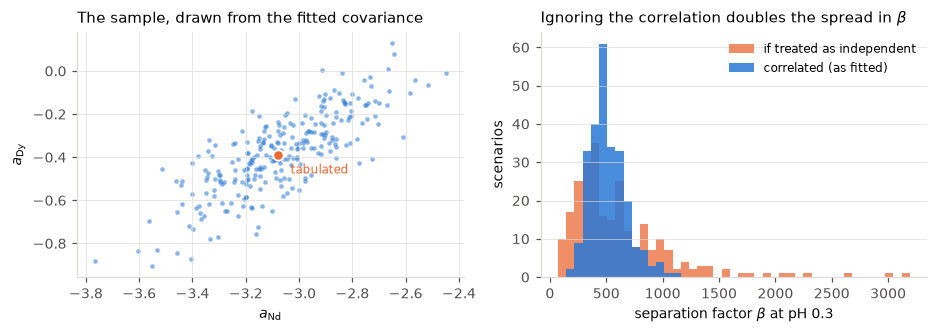

In [4]:
independent = st.ScenarioSet.from_covariance(
    ["a_Nd", "a_Dy"], A_NOM, np.diag(np.diag(COV)), n=256, seed=0)
fig_uncertainty(scenarios, independent, A_NOM, nominal, ELEMENTS);

## 3. The model

A model for `difflow.stochastic` is any pure JAX callable
`model(x, u, theta) -> {name: value}`. Nothing here is special-cased: `x` is the
first stage, `u` the recourse, `theta` one realization of the uncertainty, and
the three dicts are keyed by the names declared in the problem.

In [5]:
def circuit(x, u, theta):
    """One counter-current extraction section, priced.

    x     first stage : n_stages, solvent  -- built once, lived with forever
    u     recourse    : pH                 -- reset each campaign
    theta uncertainty : a_Nd, a_Dy         -- never revealed
    """
    # Read the levers out of one merged dict rather than naming the stage each
    # lives in. The model then does not care which stage a variable is in, and
    # moving pH from `recourse` to `first_stage` -- which is the whole
    # difference between a plant with a control loop and one without -- needs
    # no edit here at all. Section 7 does exactly that.
    lever = {**x, **u}
    solvent = lever["solvent"]

    params = REEExtractorParams(
        n_stages=lever["n_stages"], extractant="PC88A", elements=ELEMENTS,
        pH=lever["pH"], extractant_conc=1.0, include_loading=True,
        coefficient_overrides={"Nd": {"a": theta["a_Nd"]},
                               "Dy": {"a": theta["a_Dy"]}},
    )
    feed = make_stream({"H2O": WATER, **FEED}, T=298.15, P=101325.0)
    solv = make_stream({"PC88A": 0.25 * solvent, "kerosene": 0.75 * solvent},
                       T=298.15, P=101325.0)
    _, extract, _ = REEExtractor(params)(feed, solv)

    ef = get_flows(extract)
    dy, nd = ef["Dy"], ef["Nd"]
    # Oxide basis on both lines: PRICE is $/kg of RE2O3 and CLEANUP is quoted
    # the same way, so the mass factor is oxide_mw/2, never atomic_weight.
    revenue = dy * OXIDE_KG_PER_MOL["Dy"] * PRICE["Dy"] * HOURS
    cleanup = nd * OXIDE_KG_PER_MOL["Nd"] * CLEANUP * HOURS
    cost = solvent * SOLVENT_COST + lever["n_stages"] * STAGE_COST

    return {"profit": (revenue - cleanup - cost) / 1e6,   # $M/yr
            "purity": dy / (dy + nd + 1e-12),
            "recovery": dy / FEED["Dy"]}


nom = circuit({"n_stages": 6.0, "solvent": 12.0}, {"pH": 0.35},
              dict(zip(["a_Nd", "a_Dy"], A_NOM)))
print({k: round(float(v), 4) for k, v in nom.items()})

{'profit': 228.3107, 'purity': 0.9511, 'recovery': 0.9991}


Note `n_stages` is a *continuous* decision. The Kremser expression is
$E^{N+1}$, which is perfectly smooth in $N$, so the optimizer can move it and
you round at the end. Nothing above forces it to an integer.

### The split that is the whole model

| | | |
|---|---|---|
| **First stage** — *here and now* | `n_stages`, `solvent` | one value, shared by every scenario. That sharing **is** non-anticipativity: it is structural, not a constraint that could be written down wrongly. |
| **Recourse** — *wait and see* | `pH` | re-decided per campaign, once the uncertainty is known |
| **Uncertain** | `a_Nd`, `a_Dy` | never revealed |

Is pH legitimately recourse here? A distribution coefficient is *not* observable
— it is a property of the chemistry, identical in every campaign and unknown in
all of them. But the operator does not need to see $D$. They see the raffinate
assay, and they turn pH until it is on target. pH is second stage not because
$D$ was revealed but because its **consequence** was. Section 7 prices exactly
that distinction.

## 4. The problem, and the design you get by ignoring the uncertainty

The specification: Dy purity in the extract at least 0.93, with 90% confidence.
The objective is $\mathrm{CVaR}_{0.9}$ of profit — the mean of the worst decile
of campaigns — because a plant that averages well while occasionally losing
money is not the same plant as one that does not.

In [6]:
PURITY_SPEC, CONFIDENCE = 0.93, 0.90

problem = st.TwoStageProblem(
    model=circuit,
    first_stage={"n_stages": (2.0, 16.0), "solvent": (3.0, 45.0)},
    recourse={"pH": (0.1, 1.2)},          # PC88A's fitted window is [0.1, 2.5]
    objective="profit", maximize=True,
    risk=("cvar", 0.9),
    constraints=[("purity", ">=", PURITY_SPEC, CONFIDENCE)],
)
print(problem.describe())

TwoStageProblem: maximize CVaR_0.9[objective] on 'profit'
  first stage (here and now), 2 decisions:
    n_stages            [2, 16]
    solvent             [3, 45]
  recourse (wait and see), 1 decisions per scenario:
    pH                  [0.1, 1.2]
  constraints (1):
    P(purity >= 0.93) >= 0.9 [CVaR surrogate]
  auxiliary variables: 2 (Rockafellar-Uryasev)


In [7]:
options = st.SAAOptions(steps=300, rounds=6, n_starts=2)

t0 = time.time()
deterministic = st.expected_value_solution(problem, scenarios, options=options)
print(f"({time.time() - t0:.1f}s)  design at the nominal coefficients: "
      f"{ {k: round(v, 2) for k, v in deterministic.first_stage.items()} }")

(1.7s)  design at the nominal coefficients: {'n_stages': 2.53, 'solvent': 5.41}


That is the design a study that ignores the uncertainty produces: a small, cheap
section that sits exactly on its purity specification at the tabulated
coefficients. Now build it and run it for a year.

In [8]:
as_built = st.solve_recourse(problem, scenarios, deterministic.first_stage,
                             options=options)
print(as_built.summary())

# How much of that is the pH loop? Freeze pH where the nominal study left it and
# run the same 256 campaigns with no operating freedom at all.
pH_nom = float(np.ravel(deterministic.recourse["pH"])[0])
theta = {n: np.asarray(scenarios.column(n)) for n in ("a_Nd", "a_Dy")}
purity_frozen = np.array([
    float(circuit(deterministic.first_stage, {"pH": pH_nom},
                  {k: v[i] for k, v in theta.items()})["purity"])
    for i in range(scenarios.n_scenarios)
])

print()
print(f"Off spec, same design, pH FROZEN at its nominal optimum {pH_nom:.2f}:"
      f"  {100 * (purity_frozen < PURITY_SPEC).mean():.1f}% of campaigns")
print(f"Off spec, same design, pH re-optimized every campaign:          "
      f"  {100 * as_built.violation_rates[0]:.1f}% of campaigns")

SAA solution (maximize CVaR_0.9[objective] on 'profit')
  scenarios      256 (normal, seed 0)
  risk value          237.135
  mean                247.697
  sd                  5.04771
  p05 / p95           237.999 / 254.518
  first stage (one value, every scenario):
    n_stages                 2.53483
    solvent                  5.41499
  recourse (per scenario):
    variable                    mean         min         max   at bound
    pH                      0.473536    0.303452    0.676931      0.0%
  constraints (scored from the model):
    constraint                                      residual  violated
    P(purity >= 0.93) >= 0.9 [CVaR surrogate]      6.376e-08     2.7%
  feasible: True
  value_at_risk           -239.746
  tail_scenarios              25.6



Off spec, same design, pH FROZEN at its nominal optimum 0.52:  48.8% of campaigns
Off spec, same design, pH re-optimized every campaign:            2.7% of campaigns


The mean-value study signs off a small section: **2.53 stages and 5.41 mol/s
of organic**. At the tabulated coefficients, with pH at its own optimum of
0.515, that section makes a Dy purity of **0.9312** against a 0.93
specification. It is not comfortably clear of the spec; it is sitting exactly
on it, which is what optimizing against a single parameter vector always
produces.

Now build it and run 256 campaigns. Two numbers, and the gap between them is
the whole of section 7:

- **pH frozen where the nominal study left it — 48.8% of campaigns off spec.**
  Half the year outside the contract, on a section a deterministic study called
  optimal.
- **pH re-optimized every campaign — 2.7%.** Comfortably inside the 10% the
  chance constraint allows.

Two things worth reading off that before going any further:

- **A design that meets its specification at the nominal parameters is not a
  design that meets it.** Nothing about 0.9312-against-0.93 tells you what the
  tenth percentile does, and the tenth percentile is what the spec is written
  about.
- **What rescues this one is the operating loop, not the design.** The plant is
  not robust; it is *operated* out of trouble, campaign by campaign, by a lever
  the deterministic study never priced. Section 7 takes the lever away and
  prices it.

The profit spread is the other half of the story: a standard deviation of
\$5.0M across campaigns, and a worst decile averaging \$10.6M below the mean
(\$237.1M against \$247.7M).


## 5. The stochastic design

In [9]:
t0 = time.time()
stochastic = st.solve_saa(problem, scenarios, options=options)
print(f"solved in {time.time() - t0:.1f}s\n")
print(stochastic.summary())

solved in 1.2s

SAA solution (maximize CVaR_0.9[objective] on 'profit')
  scenarios      256 (normal, seed 0)
  risk value          241.009
  mean                242.697
  sd                 0.816027
  p05 / p95           241.636 / 242.889
  first stage (one value, every scenario):
    n_stages                 3.36845
    solvent                  6.21302
  recourse (per scenario):
    variable                    mean         min         max   at bound
    pH                       0.39844     0.22101     0.57813      0.0%
  constraints (scored from the model):
    constraint                                      residual  violated
   *P(purity >= 0.93) >= 0.9 [CVaR surrogate]       6.38e-06     2.7%
  feasible: False
  note: purity fails the CVaR surrogate but meets its probability empirically. The surrogate is conservative by construction, so this design may well be acceptable -- the decision is yours, not the solver's.
  value_at_risk           -242.824
  tail_scenarios              25

The stochastic design is a different plant, but not in the direction section 4
was short in: **3.37 stages and 6.21 mol/s** — a third more stages, 15% more
solvent. *Both* levers go up. With the pH loop already absorbing the level,
what is left to buy is margin against the **ratio**, and margin costs
equipment.

What it buys is not a lower violation rate — that is 2.7% either way, and both
designs clear the chance constraint — but the shape of the profit distribution.
The worst decile improves from \$237.1M to \$241.0M, and the spread across
campaigns falls by a factor of six, from a standard deviation of \$5.05M to
\$0.82M. The *mean* falls, \$247.7M to \$242.7M: $\mathrm{CVaR}_{0.9}$ was the
objective, and it traded roughly five of mean for four of tail. If that is not
the trade you want, the thing to change is the risk measure, not the solver.

Note the `feasible: False` and the line under it. The chance constraint is
enforced through a CVaR surrogate, which is conservative by construction: this
design misses the *surrogate* by 6e-6 while meeting the underlying probability
empirically, 2.7% violated against 10% allowed. The module reports both and
declines to decide which one you meant.


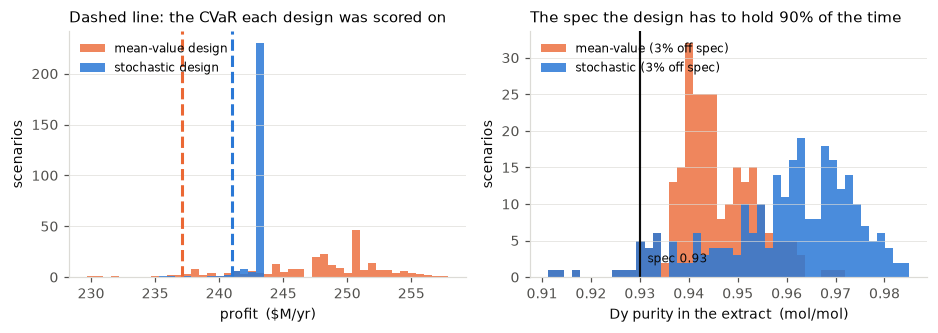

In [10]:
fig_designs(as_built, stochastic, PURITY_SPEC);

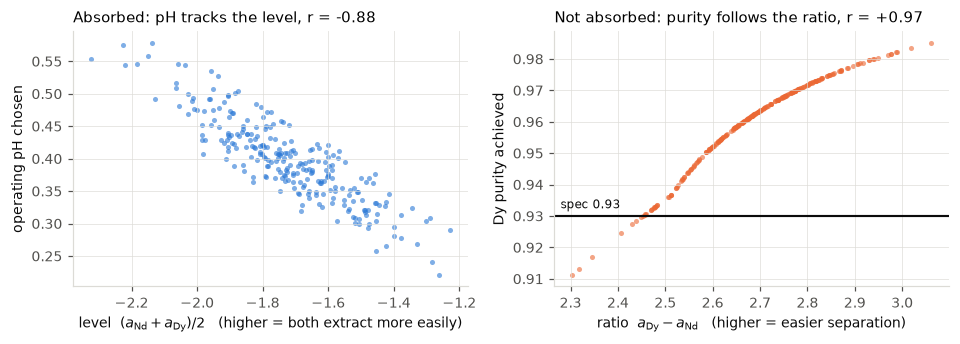

In [11]:
fig_recourse(stochastic, scenarios, PURITY_SPEC);

In [12]:
aN = np.asarray(scenarios.column("a_Nd"))
aD = np.asarray(scenarios.column("a_Dy"))
level, ratio = 0.5 * (aN + aD), aD - aN
pH_chosen = np.asarray(stochastic.recourse["pH"])
purity = np.asarray(stochastic.outputs["purity"])

print(f"{'':10}{'r with pH':>12}{'r with purity':>15}")
for name, v in (("level", level), ("ratio", ratio)):
    print(f"{name:10}{np.corrcoef(pH_chosen, v)[0, 1]:12.2f}"
          f"{np.corrcoef(purity, v)[0, 1]:15.2f}")

X = np.column_stack([np.ones_like(aN), aN, aD])
resid = pH_chosen - X @ np.linalg.lstsq(X, pH_chosen, rcond=None)[0]
print(f"\npH explained by a linear fit in (a_Nd, a_Dy):"
      f"  R^2 = {1.0 - resid.var() / pH_chosen.var():.2f}")

near = ((purity >= PURITY_SPEC) & (purity < PURITY_SPEC + 0.025)).mean()
print(f"campaigns within 0.025 above spec: {near:.1%}")
print(f"campaigns below spec:              {(purity < PURITY_SPEC).mean():.1%}")

             r with pH  r with purity
level            -0.88          -0.25
ratio            -0.22           0.97

pH explained by a linear fit in (a_Nd, a_Dy):  R^2 = 1.00
campaigns within 0.025 above spec: 27.7%
campaigns below spec:              2.7%


This is the most informative picture in the notebook, and it is not the one you
would guess. The uncertainty has two directions and the pH loop treats them
completely differently — the cell above measures it:

|  | absorbed by pH? | drives purity? |
|---|---|---|
| **level**, $(a_{\mathrm{Nd}} + a_{\mathrm{Dy}})/2$ — how strongly *both* metals extract | yes: $r(\mathrm{pH}, \text{level}) = -0.88$ | barely: $r = -0.25$ |
| **ratio**, $a_{\mathrm{Dy}} - a_{\mathrm{Nd}}$ — the separation factor | no: $r(\mathrm{pH}, \text{ratio}) = -0.22$ | almost entirely: $r = +0.97$ |

The operator is running a level-compensation loop, and a very good one: when the
chemistry turns out to extract more strongly than tabulated, pH comes down, and
vice versa, with essentially *all* of the variance in the chosen pH explained by
a linear fit in the two coefficients ($R^2 = 1.00$). That is why EVPI is about
to come out at zero — the loop already does everything advance knowledge of the
level would let you do, and it does it without knowing anything.

But pH cannot change the *ratio*. A campaign that draws a poor separation factor
gets a poor purity and there is no operating move that fixes it. 28% of
campaigns finish within 0.025 of the specification and 2.7% below it — that is
the chance constraint doing its job, and it is the residual the loop cannot
touch. It has to be carried by the **design** — the extra stages and the extra
solvent — and carrying it is the \$3.9M/yr the VSS is about to measure. The two
numbers were never in tension: recourse handles one direction of the uncertainty
and the design has to pay for the other.


## 6. Was any of this worth doing?

Two classical numbers, and they answer different questions.

$$\mathrm{VSS} = \mathrm{EEV} - \mathrm{SP} \qquad\text{was modelling the uncertainty worth it?}$$

$$\mathrm{EVPI} = \mathrm{SP} - \mathrm{WS} \qquad\text{would measuring it be worth more?}$$

EVPI compares against the unattainable plan that knows each realization in
advance, so it is an **upper bound on what any measurement can possibly be
worth**. That makes it the number to compute before commissioning a
characterization campaign.

In [13]:
t0 = time.time()
report = st.bounds(problem, scenarios, result=stochastic, options=options)
print(f"({time.time() - t0:.1f}s)\n")
print(report.summary())

(2.0s)

Stochastic-programming bounds
  wait and see  (WS)                       241.223
  stochastic    (SP)                       241.009
  mean-value design (EEV)                  237.135
  value of the stochastic solution           3.874
  expected value of perfect info          0.214293
  design                    mean-value    stochastic
  n_stages                     2.53483       3.36845
  solvent                      5.41499       6.21302


**VSS is \$3.9M/yr** — 1.6% of the worst-decile profit. That is what running the
stochastic program bought over the mean-value design, and on a section of this
size it is worth the study, but it is not a dramatic number. It is small
*because* the pH loop is doing so much: with an operator free to re-optimize
every campaign, the mean-value design is already inside its chance constraint,
and all the stochastic design can add is tail.

**EVPI is \$0.21M/yr — essentially zero.** Perfect advance knowledge of
$a_{\mathrm{Nd}}$ and $a_{\mathrm{Dy}}$ is worth almost nothing. If a lab had
offered to nail those coefficients down for \$1M, the answer from this run is
*don't buy it* — and no amount of intuition about how uncertain the chemistry is
would have told you that.

The reason is again the pH loop. It absorbs the coefficient uncertainty as fast
as the uncertainty arrives, so knowing it in advance adds nothing. Which raises
the obvious question: what is the loop itself worth?


## 7. Recourse and information are substitutes

The same problem with `pH` moved from `recourse` into `first_stage`: a section
run at one fixed operating point, campaign after campaign, whatever the assay
says. The model does not change — only which dict `pH` is read from.

It does get *harder*, and not because it has one more first-stage variable. With
the loop gone, the chance constraint has to be met by the geometry alone, so the
feasible region is a thin shell in `(n_stages, solvent, pH)` and the objective
climbs steeply toward its edge. Two multi-starts land in a poor local optimum
here; the settings below give it eight.


In [14]:
rigid_options = st.SAAOptions(steps=600, rounds=8, n_starts=8)

no_recourse = st.TwoStageProblem(
    model=circuit,
    first_stage={"n_stages": (2.0, 16.0), "solvent": (3.0, 45.0),
                 "pH": (0.1, 1.2)},                    # pH is now here-and-now
    objective="profit", maximize=True, risk=("cvar", 0.9),
    constraints=[("purity", ">=", PURITY_SPEC, CONFIDENCE)],
)
t0 = time.time()
rigid = st.bounds(no_recourse, scenarios, options=rigid_options)
print(f"({time.time() - t0:.1f}s)\n")
print(rigid.summary())


(12.0s)

Stochastic-programming bounds
  wait and see  (WS)                       241.229
  stochastic    (SP)                       167.193
  mean-value design (EEV)                  228.178
  value of the stochastic solution        -60.9852
  expected value of perfect info           74.0363
  ! the mean-value design does NOT meet the constraints under the distribution, so EEV is the objective of an inadmissible design and VSS above is not a value. Read it as: ignoring the uncertainty does not produce a usable design here.
  design                    mean-value    stochastic
  n_stages                     2.53471       4.58537
  solvent                      5.40946        5.8626
  pH                          0.515274      0.375135


In [15]:
def yn(flag):
    return "yes" if flag else "no"


print(f"{'':26s}{'with a pH loop':>16s}{'without one':>16s}")
print(f"{'CVaR_0.9 of profit':26s}{report.stochastic:16.1f}"
      f"{rigid.stochastic:16.1f}")
print(f"{'EVPI  ($M/yr)':26s}{report.evpi:16.3f}{rigid.evpi:16.1f}")
print(f"{'mean-value design usable?':26s}{yn(report.ev_feasible):>16s}"
      f"{yn(rigid.ev_feasible):>16s}")
# VSS compares against the mean-value design, so it is a value only when that
# design is one you could actually build.
print(f"{'VSS   ($M/yr)':26s}{report.vss:16.1f}"
      f"{(f'{rigid.vss:.1f}' if rigid.ev_feasible else 'not a value'):>16s}")
print()
print(f"The pH loop is worth {report.stochastic - rigid.stochastic:,.1f} $M/yr "
      f"of CVaR; EVPI without it is {rigid.evpi:,.1f}.")


                            with a pH loop     without one
CVaR_0.9 of profit                   241.0           167.2
EVPI  ($M/yr)                        0.214            74.0
mean-value design usable?              yes              no
VSS   ($M/yr)                          3.9     not a value

The pH loop is worth 73.8 $M/yr of CVaR; EVPI without it is 74.0.


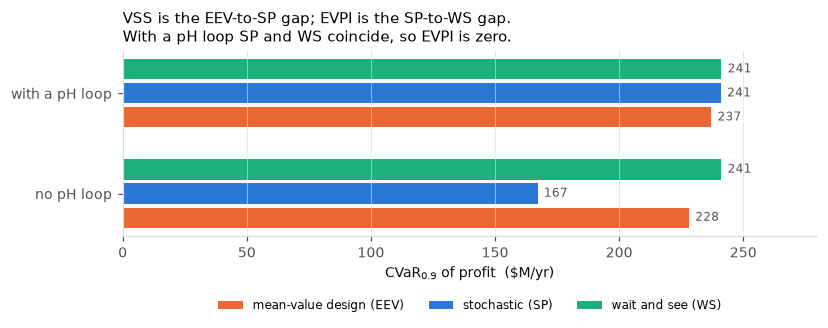

In [16]:
fig_bounds(report, rigid);

Taking the loop away costs **\$73.8M/yr of CVaR** — 241.0 with it, 167.2
without — and that is the optimistic reading, because it compares two designs
that both clear the chance constraint. The mean-value design does not: at the
rigid problem's mean-value point the section scores 228.2, better than either,
by being off spec in 49% of campaigns. `bounds` says so rather than reporting
the difference as a negative VSS, which is why the table above prints *not a
value* in that column instead of \$-61M.

That is the whole lesson of the two numbers, quantified:

- With a working pH loop, information about $D$ is worth \$0.21M/yr — the loop
  already handles it. Do not fund the characterization campaign.
- Without one, information is worth \$74M/yr — but so is *the loop*, which is
  the same \$74M and is almost certainly cheaper than resolving the chemistry.

**Recourse and information are substitutes, and the cheap one usually wins.**
Neither number is available from a deterministic study, or from propagating
uncertainty through a fixed design; they exist only once the design itself is
optimized against the distribution.

## 8. Do not trust it until it has been checked

A stochastic program will return a confident answer to a badly posed question.
`check_scenario_health` is the counterpart of `check_delta_health` in
`difflow.planning`: the things that go quietly wrong, each with a number.

In [17]:
health = st.check_scenario_health(problem, scenarios, stochastic)
print(health.summary())

Scenario health: 256 scenarios
  risk value               241.009  +/- 0.479 (sampling)
  half-sample risk         240.266
  CVaR tail                   25.6  scenarios
  first-stage lever             dRisk/dx
  n_stages                     -0.390754
  solvent                         1.5775
  findings: none


Both levers have live gradients — no `clip` or `where` has flattened one into a
dead column — the CVaR tail holds 26 scenarios rather than two, the recourse is
not pinned at a bound, and the half-sample risk sits inside the bootstrap error.

The formal version is the Mak–Morton–Wood replication bound: solve on several
*independent* samples for a bound from the optimistic side, evaluate the
candidate on one large independent sample for a bound from the achievable side,
and report the gap with a confidence limit. It is the only place in the module
that deliberately redraws the sample.

In [18]:
t0 = time.time()
gap = st.optimality_gap(problem, scenarios, stochastic, n_replications=4,
                        n_evaluation=1024, options=options)
print(f"({time.time() - t0:.1f}s)\n")
print(gap.summary())

(7.1s)

SAA optimality gap (4 replications, 1024-scenario evaluation)
  candidate value               240.536
  replication bound             240.974
  gap                          0.438305  +/- 0.621
  95% one-sided limit           1.90005
  i.e. the design is within 1.90005 of the true optimum with 95% confidence.


The bound is loose, and honestly so: with four replications the standard error
is larger than the gap itself. That is a statement about the sample size, not
about the design — and it is exactly the kind of thing that a single confident
number would have hidden. Raise `n_replications` and `n` to tighten it, at
linear cost.

## What to take away

1. **Correlation between fitted coefficients is not a detail.** Treating
   $a_{\mathrm{Nd}}$ and $a_{\mathrm{Dy}}$ as independent doubled the apparent
   uncertainty in the separation factor. Use `ScenarioSet.from_covariance` with
   the covariance your fit actually produced.
2. **Clearing a specification at the nominal parameters says nothing about the
   tail.** The mean-value design cleared 0.9312 against a 0.93 spec at the
   nominal coefficients and, held at that pH, missed the spec in 49% of
   campaigns. Letting the operator re-optimize pH each campaign took the same
   geometry to 2.7%, because pH moves the level and purity follows the ratio.
3. **VSS says whether to keep doing this.** Here it is \$3.9M/yr, small
   precisely because the pH loop absorbs most of what the stochastic design
   would otherwise have to buy with steel. A small VSS is a perfectly good
   answer, and finding it early saves the study — as is *no* VSS, which is what
   comes back when the mean-value design cannot meet the constraints at all.
4. **EVPI is the ceiling on what a measurement can be worth**, and it collapses
   when recourse can already absorb the uncertainty. Compute it *before*
   commissioning the campaign.
5. **Check the sample before believing the answer.** Dead levers, an empty CVaR
   tail and saturated recourse all produce confident nonsense.

### Where to go next

- `docs/stochastic.md` — the module, its three implementation choices, and what
  is deliberately out of scope.
- `difflow.flexibility` — when you want a *guarantee* over an envelope rather
  than a probability over a sample. Its `expected_feasibility` is the cheap
  first look at a design you already have.
- `difflow.planning.backoff` — the linear-model answer: propagate the covariance
  onto the constraint and buy `kappa * sigma` of margin. Orders of magnitude
  cheaper, and right whenever the constraint is nearly linear over the spread.
- `difflow.estimation` — where the covariance used here should come from.